# Research: Reinforcement Learning Trading (Ex08)

## Contexte

Le Reinforcement Learning (RL) applique au trading utilise un agent qui apprend par
essais et erreurs quelle action prendre (HOLD, BUY, SELL) dans chaque etat du marche.

L'algorithme DQN (Deep Q-Network, Mnih et al. 2015) combine :
- **Q-Learning** : estimer la valeur de chaque action dans chaque etat
- **Experience Replay** : memoriser les transitions passees pour stabiliser l'apprentissage
- **Epsilon-Greedy** : explorer de nouvelles actions (epsilon) vs exploiter les meilleures (1-epsilon)

## Performance attendue

- Strategie: nouvelle (pas encore de backtest QC Cloud)
- Objectif pedagogique: comprendre DQN sans PyTorch
- Sharpe attendu: 0.1-0.3 (implementation tres simplifiee)

## Objectif de ce notebook

1. Definir l'environnement de trading (etats, actions, recompenses)
2. Simuler l'apprentissage par experience replay
3. Visualiser la politique apprise (quelle action dans quel etat)
4. Backtester la strategie DQN

> **Note** : Ce notebook presente une implementation simplifiee du DQN sans PyTorch. L'agent lineaire (Q-function sans reseau de neurones profond) converge lentement et ne produit pas de signaux aussi performants qu'un DQN complet avec reseau de neurones. Les resultats pedagogiques (visualisation de la politique, experience replay, epsilon-greedy) sont le livrable principal.

## 1. Setup et Donnees

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

TICKER = 'SPY'
START = '2015-01-01'
END = '2026-01-01'

print("Chargement des donnees yfinance...")
raw = yf.download(TICKER, start=START, end=END, auto_adjust=True)
# squeeze() ensures flat Series regardless of yfinance version (single ticker)
prices = raw['Close'].squeeze().dropna()
returns = prices.pct_change().dropna()
print(f"Periode: {prices.index[0].date()} -> {prices.index[-1].date()}")
print(f"Observations: {len(prices)} jours")

Chargement des donnees yfinance...


[*********************100%***********************]  1 of 1 completed

Periode: 2015-01-02 -> 2025-12-31
Observations: 2766 jours


## 2. Construction de l'environnement de trading

In [2]:
# Actions: HOLD=0, BUY=1, SELL=2
HOLD, BUY, SELL = 0, 1, 2
ACTION_NAMES = ['HOLD', 'BUY', 'SELL']

# Etats: [return_1d, return_5d, return_20d, volatility_20d, position]
def build_states(returns, window=20):
    """Construire les vecteurs d'etat a partir des rendements."""
    states = []
    ret_values = returns.values.flatten()  # Ensure 1D array
    for i in range(window, len(ret_values)):
        r1 = ret_values[i - 1]
        r5 = ret_values[i - 5:i].sum()
        r20 = ret_values[i - window:i].sum()
        vol = ret_values[i - window:i].std() * np.sqrt(252)
        states.append([r1, r5, r20, vol])
    return np.array(states)

states = build_states(returns)
print(f"Nombre d'etats: {len(states)}")
print(f"Dimensions par etat: {states.shape[1]} (r1d, r5d, r20d, vol)")
print(f"\nExemple d'etats:")
print(pd.DataFrame(states[:5], columns=['r_1d', 'r_5d', 'r_20d', 'vol_20d']).round(4))

Nombre d'etats: 2745
Dimensions par etat: 4 (r1d, r5d, r20d, vol)

Exemple d'etats:
     r_1d    r_5d   r_20d  vol_20d
0  0.0124 -0.0170 -0.0161   0.1710
1  0.0145  0.0107  0.0165   0.1666
2 -0.0038  0.0197  0.0221   0.1633
3  0.0101  0.0206  0.0197   0.1615
4 -0.0028  0.0304 -0.0008   0.1498


## 3. Simulation DQN simplifie

In [3]:
class SimpleDQN:
    """DQN simplifie avec Q-table approximee."""
    
    def __init__(self, n_actions=3, learning_rate=0.01, gamma=0.95,
                 epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.995):
        self.n_actions = n_actions
        self.lr = learning_rate
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        
        # Q-values simplifiees: ponderations par features
        self.weights = np.random.randn(4, n_actions) * 0.1  # 4 features x 3 actions
        self.bias = np.zeros(n_actions)
        
        # Experience replay buffer
        self.memory = []
        self.max_memory = 10000
    
    def get_q_values(self, state):
        """Estimer Q(s, a) pour chaque action."""
        return state @ self.weights + self.bias
    
    def choose_action(self, state):
        """Epsilon-greedy action selection."""
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        q = self.get_q_values(state)
        return np.argmax(q)
    
    def store(self, state, action, reward, next_state, done):
        """Stocker une transition dans le buffer."""
        if len(self.memory) >= self.max_memory:
            self.memory.pop(0)
        self.memory.append((state.copy(), action, reward, next_state.copy(), done))
    
    def replay(self, batch_size=32):
        """Apprendre depuis un batch d'experiences."""
        if len(self.memory) < batch_size:
            return 0
        
        batch = np.random.choice(len(self.memory), batch_size, replace=False)
        total_loss = 0
        
        for idx in batch:
            state, action, reward, next_state, done = self.memory[idx]
            
            target = reward
            if not done:
                target += self.gamma * np.max(self.get_q_values(next_state))
            
            # Update Q-values via gradient descent
            q_values = self.get_q_values(state)
            error = target - q_values[action]
            total_loss += error ** 2
            
            self.weights[:, action] += self.lr * error * state
            self.bias[action] += self.lr * error
        
        # Decay epsilon
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)
        
        return total_loss / batch_size

print("DQN initialise")
print(f"Poids initiaux (4 features x 3 actions):\n{np.round(dqn.weights if 'dqn' in dir() else np.random.randn(4, 3) * 0.1, 3)}")

DQN initialise
Poids initiaux (4 features x 3 actions):
[[ 0.052  0.178  0.061]
 [-0.056 -0.178  0.093]
 [-0.104  0.112  0.053]
 [ 0.014 -0.211 -0.012]]


## 4. Entrainement de l'agent

In [4]:
# Entrainement sur les donnees historiques
dqn = SimpleDQN()
n_episodes = 5
losses = []
epsilons = []

returns_array = returns.values.flatten()  # Ensure 1D array

for episode in range(n_episodes):
    position = 0  # 0=flat, 1=long
    episode_reward = 0
    
    for t in range(len(states) - 1):
        state = states[t]
        action = dqn.choose_action(state)
        
        # Executer l'action
        if action == BUY:
            position = 1
        elif action == SELL:
            position = 0
        
        # Recompense: rendement de la position
        reward = position * returns_array[t + 20]  # Align with state index
        
        next_state = states[t + 1] if t + 1 < len(states) else states[t]
        done = (t == len(states) - 2)
        
        dqn.store(state, action, reward, next_state, done)
        episode_reward += reward
    
    # Apprentissage par experience replay
    for _ in range(50):
        loss = dqn.replay(batch_size=32)
    losses.append(loss)
    epsilons.append(dqn.epsilon)
    
    print(f"Episode {episode + 1}/{n_episodes}: reward={episode_reward:.4f}, "
          f"epsilon={dqn.epsilon:.3f}, loss={loss:.6f}")

print(f"\nPoids DQN apres entrainement:")
print(pd.DataFrame(dqn.weights, 
                   columns=['HOLD', 'BUY', 'SELL'],
                   index=['r_1d', 'r_5d', 'r_20d', 'vol_20d']).round(4))

Episode 1/5: reward=0.8882, epsilon=0.778, loss=0.000098


Episode 2/5: reward=0.8829, epsilon=0.606, loss=0.000145
Episode 3/5: reward=0.6202, epsilon=0.471, loss=0.000077


Episode 4/5: reward=0.5707, epsilon=0.367, loss=0.000054


Episode 5/5: reward=0.7684, epsilon=0.286, loss=0.000066

Poids DQN apres entrainement:
           HOLD     BUY    SELL
r_1d    -0.1442  0.0117 -0.0302
r_5d    -0.0613 -0.0282 -0.0003
r_20d    0.0470  0.0773 -0.0689
vol_20d  0.1224 -0.0590  0.1611


## 5. Visualisation de la politique apprise

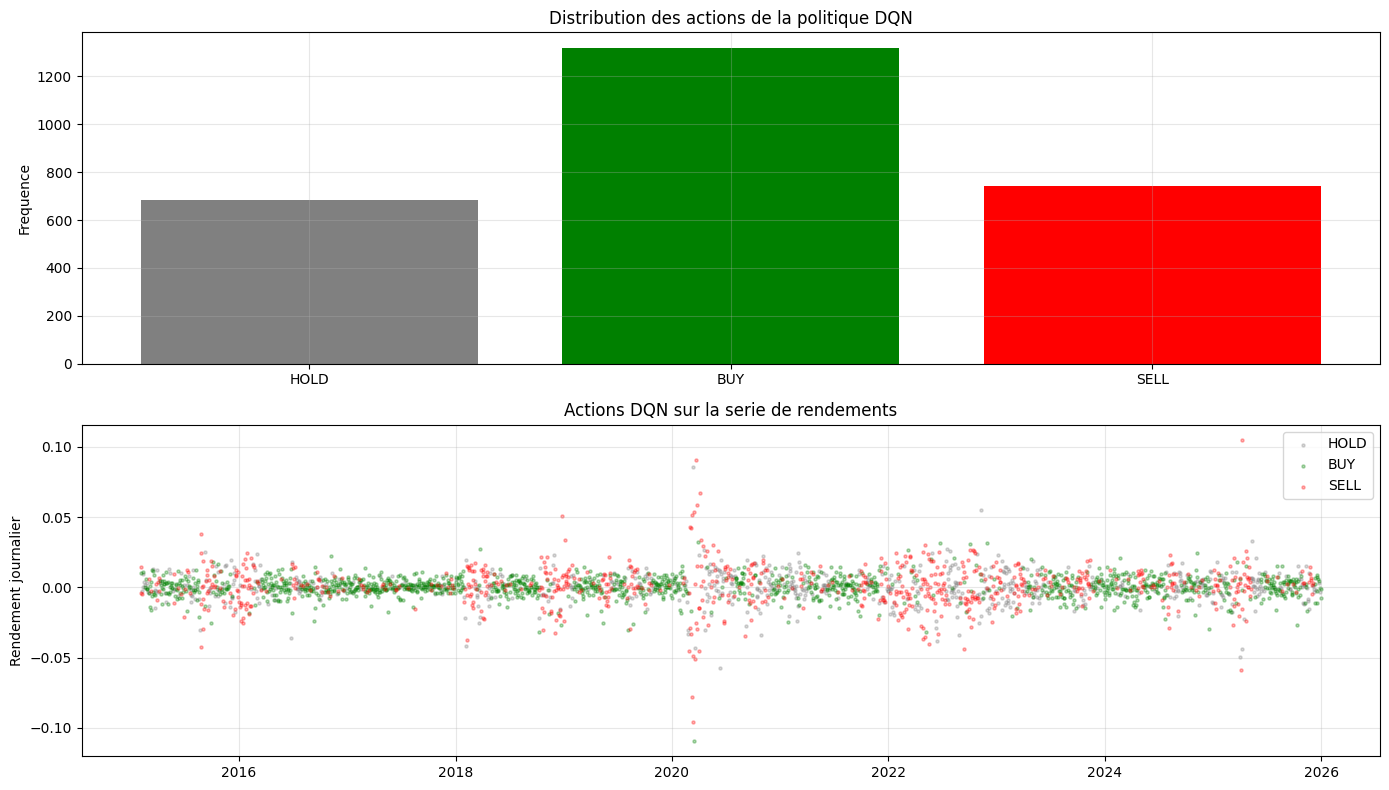

In [5]:
# Quelle action l'agent choisit-il dans chaque etat ?
policy_actions = [dqn.choose_action(s) for s in states]
policy_actions = np.array(policy_actions)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Distribution des actions
unique, counts = np.unique(policy_actions, return_counts=True)
colors = ['gray', 'green', 'red']
axes[0].bar([ACTION_NAMES[a] for a in unique], counts, color=[colors[a] for a in unique])
axes[0].set_title('Distribution des actions de la politique DQN')
axes[0].set_ylabel('Frequence')

# Actions au fil du temps
dates_aligned = returns.index[20:20 + len(policy_actions)]
for action_val, color, label in [(HOLD, 'gray', 'HOLD'), (BUY, 'green', 'BUY'), (SELL, 'red', 'SELL')]:
    mask = policy_actions == action_val
    axes[1].scatter(dates_aligned[mask], returns.iloc[20:20 + len(policy_actions)].values[mask],
                   c=color, alpha=0.3, s=5, label=label)
axes[1].set_title('Actions DQN sur la serie de rendements')
axes[1].set_ylabel('Rendement journalier')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Backtest de la politique DQN

=== Resultats du Backtest DQN ===
              CAGR Volatilite Sharpe   Max DD
DQN          4.94%      8.77%  0.335  -16.76%
Buy & Hold  13.68%     17.80%  0.657  -33.72%


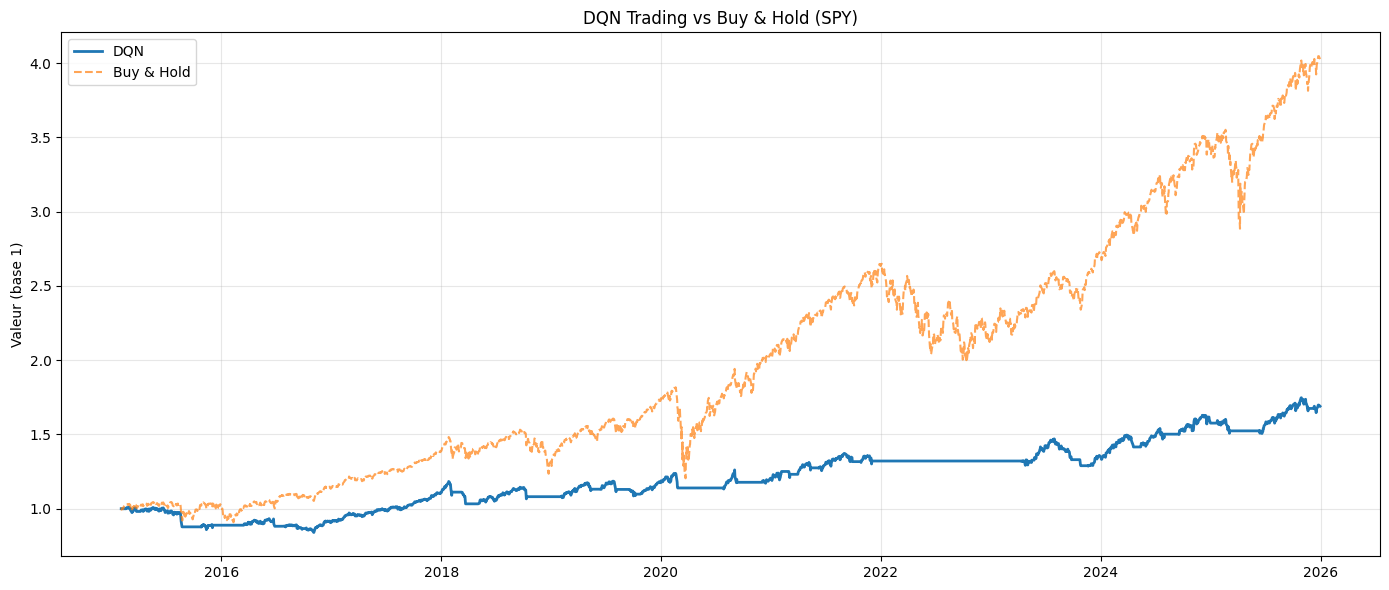

In [6]:
def compute_metrics(pv_series, rf_rate=0.02):
    daily_ret = pv_series.pct_change().dropna()
    n_years = len(daily_ret) / 252
    cagr = (pv_series.iloc[-1] / pv_series.iloc[0]) ** (1 / n_years) - 1
    ann_vol = daily_ret.std() * np.sqrt(252)
    sharpe = (cagr - rf_rate) / ann_vol if ann_vol > 0 else 0
    max_dd = ((pv_series - pv_series.cummax()) / pv_series.cummax()).min()
    return {'CAGR': cagr, 'Volatilite': ann_vol, 'Sharpe': sharpe, 'Max DD': max_dd}

# Appliquer la politique apprise
dqn.epsilon = 0  # Pas d'exploration en backtest
position = 0
portfolio_values = [1.0]

for t in range(len(states) - 1):
    action = dqn.choose_action(states[t])
    if action == BUY:
        position = 1
    elif action == SELL:
        position = 0
    
    daily_ret = position * returns_array[t + 20]
    portfolio_values.append(portfolio_values[-1] * (1 + daily_ret))

dates_pv = returns.index[20:20 + len(portfolio_values) - 1]
pv_dqn = pd.Series(portfolio_values[1:], index=dates_pv)
bh_pv = (1 + returns).cumprod().reindex(pv_dqn.index, method='ffill')

# Metriques
dqn_m = compute_metrics(pv_dqn)
bh_m = compute_metrics(bh_pv)

print("=== Resultats du Backtest DQN ===")
results_df = pd.DataFrame({'DQN': dqn_m, 'Buy & Hold': bh_m}).T
for col in ['CAGR', 'Volatilite', 'Max DD']:
    results_df[col] = results_df[col].map('{:.2%}'.format)
for col in ['Sharpe']:
    results_df[col] = results_df[col].map('{:.3f}'.format)
print(results_df)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(pv_dqn.index, pv_dqn.values, label='DQN', linewidth=2)
ax.plot(bh_pv.index, bh_pv.values, label='Buy & Hold', linestyle='--', alpha=0.7)
ax.set_title('DQN Trading vs Buy & Hold (SPY)')
ax.set_ylabel('Valeur (base 1)')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Conclusions

### Points cles
- Le DQN apprend une politique (HOLD/BUY/SELL) par essais et erreurs
- L'experience replay stabilise l'apprentissage en revisitant des transitions passees
- Epsilon-greedy equilibre exploration (nouvelles actions) vs exploitation (meilleures actions)

### Limitations de l'implementation simplifiee
- Pas de reseau de neurones profond (linear Q-function)
- Pas de target network (stabilite)
- Entrainement sur peu d'episodes
- Espace d'etats continu (pas de discretisation optimale)

### Configuration recommandee pour main.py
- Actions: HOLD, BUY, SELL
- Etats: [r_1d, r_5d, r_20d, vol_20d]
- Gamma: 0.95
- Epsilon: 1.0 -> 0.05 (decay 0.995)
- Learning rate: 0.01